In [3]:
import warnings
warnings.filterwarnings("ignore")

!pip install catboost

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, classification_report,
    RocCurveDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline as ImbPipeline

RANDOM_STATE = 12
sns.set_theme(style="darkgrid")
pd.set_option("display.max_columns", None)

In [4]:
DATA_PATH = "credit_risk_dataset.csv"

data = pd.read_csv(DATA_PATH)

print("Dataset shape:", data.shape)
print("\nColumns:")
print(data.columns.tolist())

required_columns = [
    "person_age", "person_income", "person_home_ownership",
    "person_emp_length", "loan_intent", "loan_grade",
    "loan_amnt", "loan_int_rate", "loan_status",
    "loan_percent_income", "cb_person_default_on_file",
    "cb_person_cred_hist_length"
]

missing_required = sorted(set(required_columns) - set(data.columns))
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

data.head()

Dataset shape: (32581, 12)

Columns:
['person_age', 'person_income', 'person_home_ownership', 'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length']


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


## 1. Initial EDA

In [5]:
display(data.sample(6, random_state=RANDOM_STATE).reset_index(drop=True))
print("Shape:", data.shape)
display(data.describe(include="all").T)

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,23,28800,RENT,4.0,MEDICAL,B,6000,NaN,0,0.21,N,3
1,35,75000,MORTGAGE,9.0,EDUCATION,A,10000,7.29,0,0.13,N,9
2,27,157544,MORTGAGE,8.0,VENTURE,C,35000,12.99,0,0.22,N,8
3,28,108041,MORTGAGE,6.0,EDUCATION,C,5600,13.98,0,0.05,Y,7
4,27,108928,MORTGAGE,9.0,EDUCATION,A,17600,7.88,0,0.16,N,8
5,21,18000,RENT,1.0,PERSONAL,A,3200,8.49,1,0.18,N,3


Shape: (32581, 12)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
person_age,32581.0,NaN,NaN,NaN,27.7346,6.348078,20.0,23.0,26.0,30.0,144.0
person_income,32581.0,NaN,NaN,NaN,66074.84847,61983.119168,4000.0,38500.0,55000.0,79200.0,6000000.0
person_home_ownership,32581,4,RENT,16446,NaN,NaN,NaN,NaN,NaN,NaN,NaN
person_emp_length,31686.0,NaN,NaN,NaN,4.789686,4.14263,0.0,2.0,4.0,7.0,123.0
loan_intent,32581,6,EDUCATION,6453,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_grade,32581,7,A,10777,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_amnt,32581.0,NaN,NaN,NaN,9589.371106,6322.086646,500.0,5000.0,8000.0,12200.0,35000.0
loan_int_rate,29465.0,NaN,NaN,NaN,11.011695,3.240459,5.42,7.9,10.99,13.47,23.22
loan_status,32581.0,NaN,NaN,NaN,0.218164,0.413006,0.0,0.0,0.0,0.0,1.0
loan_percent_income,32581.0,NaN,NaN,NaN,0.170203,0.106782,0.0,0.09,0.15,0.23,0.83


In [6]:
missing = data.isna().sum().sort_values(ascending=False)
missing_pct = (data.isna().mean() * 100).sort_values(ascending=False)

missing_summary = pd.DataFrame({
    "missing_count": missing,
    "missing_percent": missing_pct.round(2)
})
display(missing_summary[missing_summary["missing_count"] > 0])

,missing_count,missing_percent
loan_int_rate,3116,9.56
person_emp_length,895,2.75


Duplicate rows: 165

Target distribution:


,count
loan_status,
0,25473
1,7108


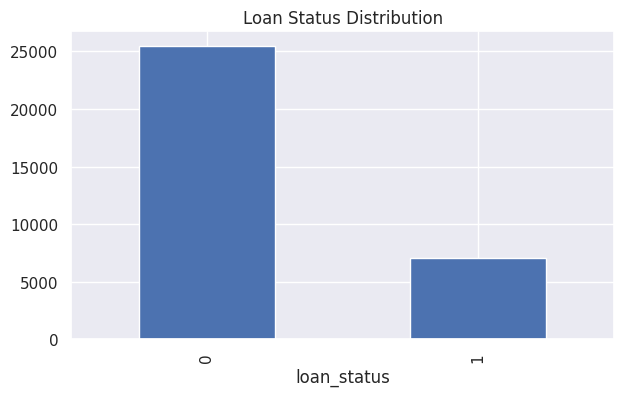

In [7]:
print("Duplicate rows:", data.duplicated().sum())
print("\nTarget distribution:")
display(data["loan_status"].value_counts().rename_axis("loan_status").to_frame("count"))

plt.figure(figsize=(7, 4))
data["loan_status"].value_counts().sort_index().plot(kind="bar", ax=plt.gca())
plt.title("Loan Status Distribution")
plt.show()

## 2. Data Quality Corrections

In [8]:
# The dataset contains clearly implausible outliers:
# person_age reaches 144 and person_emp_length reaches 123.
# These are treated as invalid records rather than normal observations.

clean_data = data.copy()

before = len(clean_data)
clean_data = clean_data[
    (clean_data["person_age"] <= 80) &
    (clean_data["person_emp_length"].fillna(0) <= 60)
].copy()

print(f"Rows before invalid-value removal: {before}")
print(f"Rows after invalid-value removal:  {len(clean_data)}")
print(f"Rows removed: {before - len(clean_data)}")

# Remove exact duplicate records.
before_dup = len(clean_data)
clean_data = clean_data.drop_duplicates().reset_index(drop=True)
print(f"Duplicate rows removed: {before_dup - len(clean_data)}")

display(clean_data.describe().T)

Rows before invalid-value removal: 32581
Rows after invalid-value removal:  32572
Rows removed: 9
Duplicate rows removed: 165


,count,mean,std,min,25%,50%,75%,max
person_age,32407.0,27.726973,6.191831,20.00,23.00,26.00,30.00,80.00
person_income,32407.0,65894.677847,52518.729472,4000.00,38500.00,55000.00,79200.00,2039784.00
person_emp_length,31520.0,4.783058,4.037384,0.00,2.00,4.00,7.00,41.00
loan_amnt,32407.0,9592.569507,6321.056427,500.00,5000.00,8000.00,12250.00,35000.00
loan_int_rate,29314.0,11.017219,3.241709,5.42,7.90,10.99,13.47,23.22
loan_status,32407.0,0.218718,0.413383,0.00,0.00,0.00,0.00,1.00
loan_percent_income,32407.0,0.170247,0.106786,0.00,0.09,0.15,0.23,0.83
cb_person_cred_hist_length,32407.0,5.809979,4.055058,2.00,3.00,4.00,8.00,30.00


In [9]:
# Useful derived features. They are deterministic transformations of existing fields.
clean_data["loan_to_income_ratio"] = (
    clean_data["loan_amnt"] / clean_data["person_income"].replace(0, np.nan)
)

clean_data["loan_to_emp_length_ratio"] = (
    clean_data["person_emp_length"] / clean_data["loan_amnt"].replace(0, np.nan)
)

clean_data["int_rate_to_loan_amt_ratio"] = (
    clean_data["loan_int_rate"] / clean_data["loan_amnt"].replace(0, np.nan)
)

display(clean_data.head())

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_to_income_ratio,loan_to_emp_length_ratio,int_rate_to_loan_amt_ratio
0,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2,0.104167,0.005000,0.011140
1,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3,0.572917,0.000182,0.002340
2,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2,0.534351,0.000114,0.000435
3,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4,0.643382,0.000229,0.000408
4,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2,0.252525,0.000800,0.002856


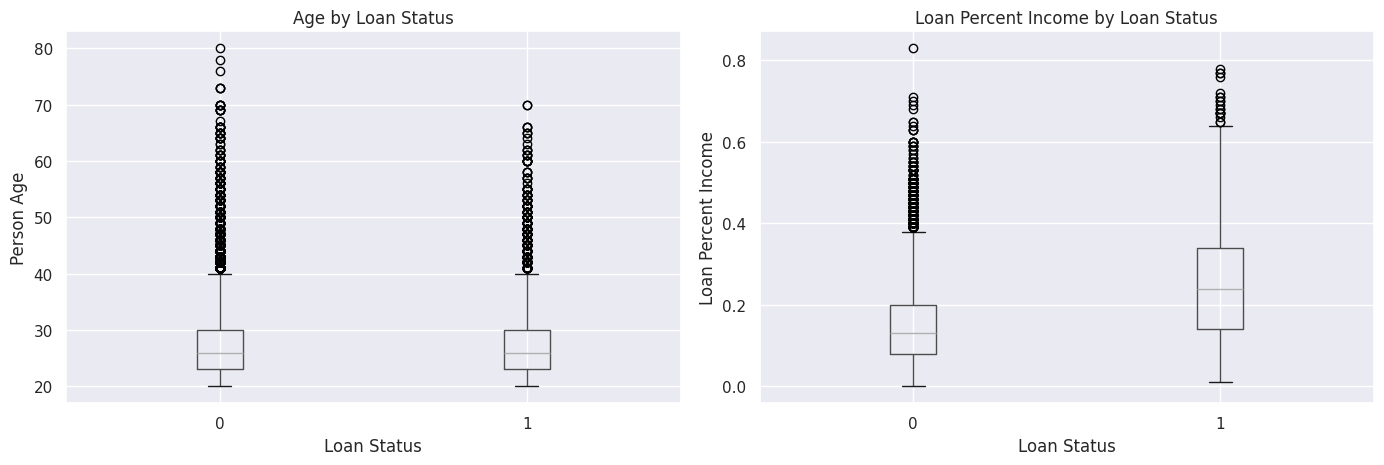

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

clean_data.boxplot(column="person_age", by="loan_status", ax=axes[0])
axes[0].set_title("Age by Loan Status")
axes[0].set_xlabel("Loan Status")
axes[0].set_ylabel("Person Age")

clean_data.boxplot(column="loan_percent_income", by="loan_status", ax=axes[1])
axes[1].set_title("Loan Percent Income by Loan Status")
axes[1].set_xlabel("Loan Status")
axes[1].set_ylabel("Loan Percent Income")
plt.suptitle("")
plt.tight_layout()
plt.show()

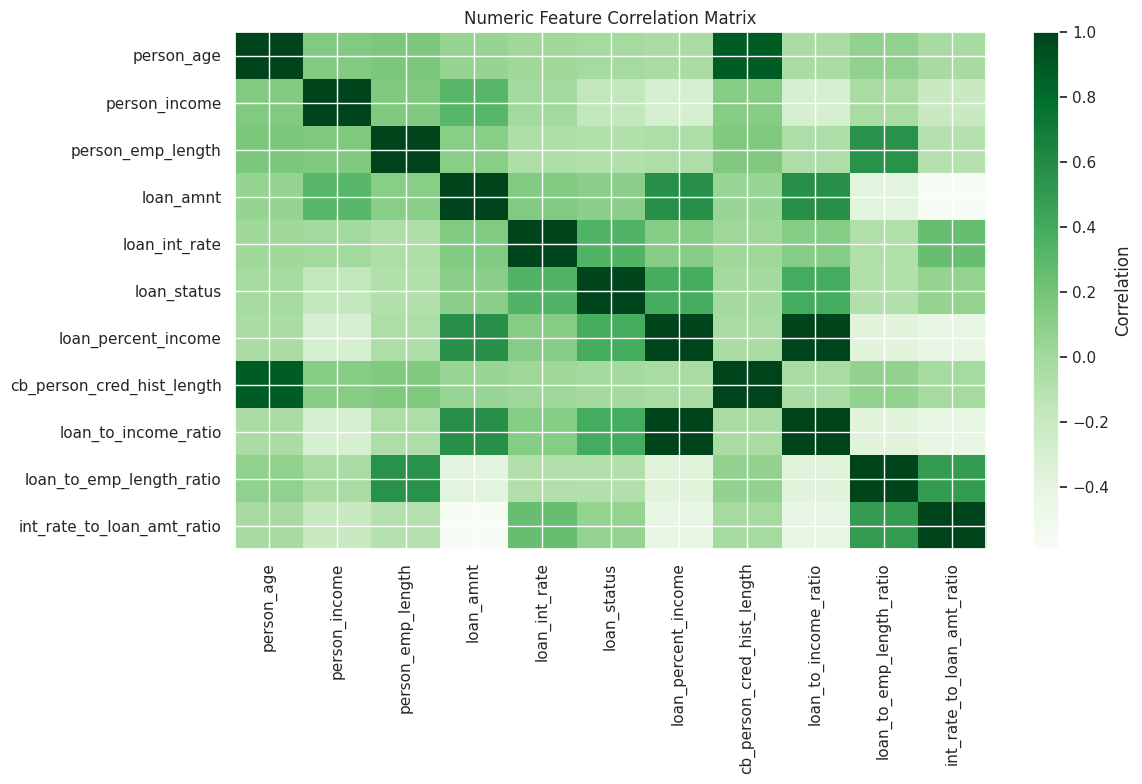

In [11]:
numeric_cols_for_corr = clean_data.select_dtypes(include=np.number).columns
corr = clean_data[numeric_cols_for_corr].corr()
plt.figure(figsize=(12, 8))
plt.imshow(corr, cmap="Greens", aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Numeric Feature Correlation Matrix")
plt.tight_layout()
plt.show()

## 3. Train/Test Split and Leakage-Safe Preprocessing

In [12]:
X = clean_data.drop(columns=["loan_status"])
y = clean_data["loan_status"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())
print("\nTest target distribution:")
print(y_test.value_counts())

X_train: (25925, 14)
X_test:  (6482, 14)

Training target distribution:
loan_status
0    20255
1     5670
Name: count, dtype: int64

Test target distribution:
loan_status
0    5064
1    1418
Name: count, dtype: int64


In [13]:
numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=np.number).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

Numeric features: ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'loan_to_income_ratio', 'loan_to_emp_length_ratio', 'int_rate_to_loan_amt_ratio']
Categorical features: ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']


## 4. Handle Class Imbalance Correctly

In [14]:
# IMPORTANT:
# RandomOverSampler is fitted only on X_train/y_train.
# The test set is NEVER oversampled, so evaluation remains realistic.

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

ros = RandomOverSampler(random_state=RANDOM_STATE)
X_res, y_res = ros.fit_resample(X_train_processed, y_train)

print("Before ROS:", X_train_processed.shape, y_train.value_counts().to_dict())
print("After ROS: ", X_res.shape, pd.Series(y_res).value_counts().to_dict())
print("Test set:  ", X_test_processed.shape, y_test.value_counts().to_dict())

Before ROS: (25925, 29) {0: 20255, 1: 5670}
After ROS:  (40510, 29) {0: 20255, 1: 20255}
Test set:   (6482, 29) {0: 5064, 1: 1418}


### Equivalent correction for the earlier line

Instead of:

```python
xres, yres = ros.fit_resample(x, y)
```

use the training data only:

```python
X_res, y_res = ros.fit_resample(X_train_processed, y_train)
```

The test set must remain untouched.

## 5. Classification Models

In [15]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000, random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1,
        class_weight=None
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "CatBoost": CatBoostClassifier(
        iterations=300,
        depth=6,
        learning_rate=0.05,
        verbose=0,
        random_seed=RANDOM_STATE
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        random_state=RANDOM_STATE,
        verbosity=-1
    )
}

In [16]:
def evaluate_classifier(name, model, X_train_data, y_train_data, X_test_data, y_test_data):
    model.fit(X_train_data, y_train_data)
    pred = model.predict(X_test_data)

    if hasattr(model, "predict_proba"):
        prob = model.predict_proba(X_test_data)[:, 1]
    else:
        prob = None

    tn, fp, fn, tp = confusion_matrix(y_test_data, pred, labels=[0, 1]).ravel()
    specificity = tn / (tn + fp) if (tn + fp) else 0.0

    result = {
        "Model": name,
        "Accuracy": accuracy_score(y_test_data, pred),
        "Precision": precision_score(y_test_data, pred, zero_division=0),
        "Recall": recall_score(y_test_data, pred, zero_division=0),
        "F1": f1_score(y_test_data, pred, zero_division=0),
        "Specificity": specificity,
        "ROC-AUC": roc_auc_score(y_test_data, prob) if prob is not None else np.nan
    }
    return result, pred, prob

results = []
fitted_models = {}
predictions = {}
probabilities = {}

for name, model in models.items():
    result, pred, prob = evaluate_classifier(
        name, model, X_res, y_res, X_test_processed, y_test
    )
    results.append(result)
    fitted_models[name] = model
    predictions[name] = pred
    probabilities[name] = prob

results_df = pd.DataFrame(results).sort_values("ROC-AUC", ascending=False).reset_index(drop=True)
display(results_df.round(4))

,Model,Accuracy,Precision,Recall,F1,Specificity,ROC-AUC
0,LightGBM,0.9269,0.8682,0.7849,0.8244,0.9666,0.9493
1,XGBoost,0.9238,0.8484,0.7934,0.8200,0.9603,0.9472
2,CatBoost,0.9144,0.8262,0.7708,0.7975,0.9546,0.9395
3,Random Forest,0.9321,0.9429,0.7341,0.8255,0.9876,0.9332
4,Logistic Regression,0.8214,0.5653,0.7934,0.6602,0.8292,0.8822


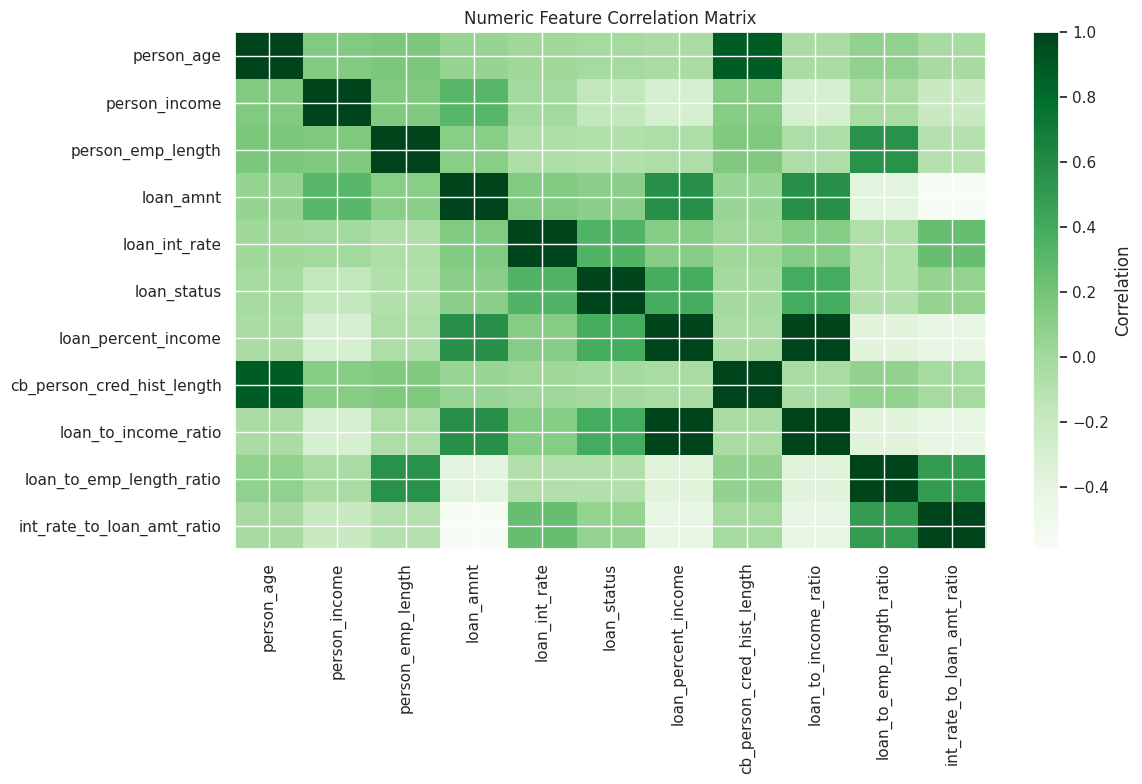

In [17]:
numeric_cols_for_corr = clean_data.select_dtypes(include=np.number).columns
corr = clean_data[numeric_cols_for_corr].corr()
plt.figure(figsize=(12, 8))
plt.imshow(corr, cmap="Greens", aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Numeric Feature Correlation Matrix")
plt.tight_layout()
plt.show()

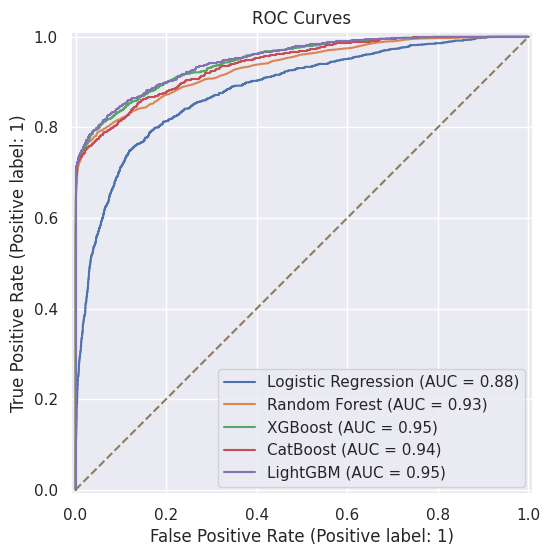

In [18]:
plt.figure(figsize=(8, 6))

for name, prob in probabilities.items():
    if prob is not None:
        RocCurveDisplay.from_predictions(
            y_test, prob, name=name, ax=plt.gca()
        )

plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curves")
plt.show()

## 6. Soft Voting Ensemble

In [19]:
# A simple ensemble of the three strongest tree/boosting learners.
ensemble = VotingClassifier(
    estimators=[
        ("rf", RandomForestClassifier(
            n_estimators=250, random_state=RANDOM_STATE, n_jobs=-1
        )),
        ("xgb", XGBClassifier(
            n_estimators=250, max_depth=6, learning_rate=0.05,
            subsample=0.9, colsample_bytree=0.9,
            eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1
        )),
        ("lgb", LGBMClassifier(
            n_estimators=250, learning_rate=0.05,
            num_leaves=31, random_state=RANDOM_STATE, verbosity=-1
        ))
    ],
    voting="soft"
)

ensemble_result, ensemble_pred, ensemble_prob = evaluate_classifier(
    "Voting Ensemble",
    ensemble,
    X_res, y_res,
    X_test_processed, y_test
)

display(pd.DataFrame([ensemble_result]).round(4))

,Model,Accuracy,Precision,Recall,F1,Specificity,ROC-AUC
0,Voting Ensemble,0.9315,0.9079,0.7645,0.83,0.9783,0.9488


## 7. Feature Importance

,importance
num__loan_to_income_ratio,0.149742
num__loan_int_rate,0.118646
num__person_income,0.112615
num__loan_percent_income,0.108241
num__int_rate_to_loan_amt_ratio,0.056889
cat__loan_grade_D,0.047280
num__loan_amnt,0.046460
num__loan_to_emp_length_ratio,0.044509
cat__person_home_ownership_RENT,0.036389
num__person_age,0.035780


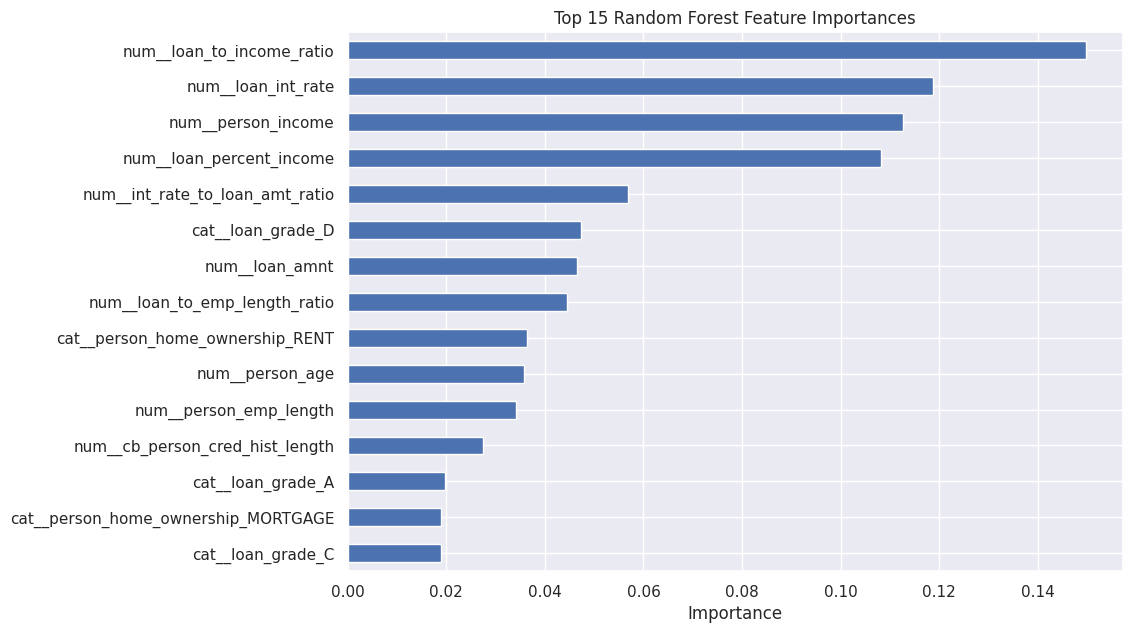

In [20]:
# Train a Random Forest classifier for feature importance.
rf_for_importance = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_for_importance.fit(X_res, y_res)

feature_names = preprocessor.get_feature_names_out()
importance = pd.Series(
    rf_for_importance.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

display(importance.head(20).to_frame("importance"))

plt.figure(figsize=(10, 7))
importance.head(15).sort_values().plot(kind="barh")
plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.show()

## 8. Optional AutoML

In [21]:
# PyCaret and AutoGluon were removed from the main execution path because they are
# optional external packages and were not installed in the original environment.
# The core notebook above is fully independent of them.
#
# If you already have PyCaret installed, you can use:
#
# from pycaret.classification import setup, compare_models
# automl_setup = setup(data=clean_data, target="loan_status", session_id=RANDOM_STATE)
# best_automl = compare_models()
#
# If you already have AutoGluon installed, use a separate train/test dataframe
# containing the original categorical columns and the target.